---
title: "Risk Score Calculation in NIPT jupyter"
author: "Duy Dao"
date: today
date-format: long
---

# Risk Score

## Terminology

Risk factors (priori risk):

- Maternal age
- Likelihood from nuchal translucency thickness
- Serum pregnancy-associated plasma protein-A
- Serum free B-human chorionic gonadotropin and plasma cfDNA

Positive likelihood ratio (trisomic/euploid)
Negative likelihood ratio (euploid/trisomic)

Posteriori risk (Sikkema-Raddatz et al., 2016)
> True likelihood of carrying a foetus with trisomy

Conditional Probability (https://en.wikipedia.org/wiki/Conditional_probability)

## Reference Application

### NIPTRIC: an online tool for clinical interpretation of non-invasive prenatal testing (NIPT) results

![alt text](image.png)

The tool takes input:
- a priori risk
- z-score 

PPR can be calculated for combitionations of the 4 parameters:
- a priori risk
- observed z-score
- fetal fraction
- coefficient of variation (CV)

Output:

- PPR (Personalized Posteriori Risk)

> "For z<5, PPR is considerably higher at a high a priori risk than at a low a priori risk"

> "The PPR is effectively **independent** under all conditions for Z-scores above 6"

When the count was too high, then the PPR is no more dependent on the a priori risk. No matter how prevalent the condition is, a very high z-score is very likely to be a true positive.

#### What is an "a priori risk"?


her a priori risk for a specific foetal trisomy:

- her age
- the gestational age

> "presenting NIPT results to clinicians and pregnant women as “normal or abnormal” or as a Z-score makes it difficult for clinicians to interpret and use the result to correctly inform a pregnant woman of her true likelihood of carrying a foetus with a trisomy"

True chance of carrying a foetus with a positive test

![Personalized a posteriori risk](image-1.png)

### The PPR calculator

4 input parameters:
- a priori risk (calculated based on the mother’s age and gestational age, or based on other screening tests)
- z-score
- fetal fraction
- coefficient of variation of the control group

### a priori risk

a priori risk from Trisomy 21

[Maternal age- and gestation-specific risk for trisomy 21](https://pubmed.ncbi.nlm.nih.gov/10204206/)

Can I categoize these priori risk for each syndrome?

bivariate linear interpolation

use bivariate linear interpolation to calculate the `a priori risk` from the maternal age in combination with the gestational age at which the NIPT was performed.


**First trimester combined test (FCT)**

> The first-trimester combined test (FCT) is a prenatal screening that assesses the risk of chromosomal abnormalities, such as Down syndrome, by combining maternal age, a nuchal translucency (NT) ultrasound, and blood levels of two hormones: free β-human chorionic gonadotropin (β-hCG) and pregnancy-associated plasma protein A (PAPP-A).


**Z-score**

> A Z-score represents the number of standard deviations that the sample fraction of that chromosome deviates from the mean measured in normal (diploid) pregnancies assessed by a Gaussian distribution.

**Distinction between "normal" and "abnormal" NIPT results**

> The distinction is based on the statistical assumption that 99.7% of the plasma samples derived from pregnant women with a diploid foetus give a Z-score between −3 and +3.

The more the `Z-score` deviates from zero, the more the `individual sample` deviates from the `control group` and thus points towards an `aneuploidy`.






::: {.callout-note title="Important Note"}

The higher value of the Z-score for aneuploid samples, and thus the reliability of NIPT, however, depends on the `assay precision` which, in turn, depends on a number of factors such as the number of reads, the reference samples chosen, the method of sample preparation, and sequencing method. All these factors are encompassed in the coefficient of variation of control samples and, together with the percentage of foetal DNA in the maternal plasma, they influence the Z-score.

:::

**Fetal fraction**

Given a weight for each fetal fraction

#### Coefficient of Variation

> The random variability of the test is measured as the coefficient of variation of the control group.
>
> The coefficient will increase as the assay precision decreases, depending on the quality of the laboratory procedure, i.e. sample preparation or number of reads.
>

![image.png](attachment:image.png)

![image-2.png](attachment:image-2.png)

> Increasing the number of reads can improve the assay precision and thus reduce the coefficient of variation of the control group.

**Practical Example**

Imagine we're analyzing chromosome 21 in maternal blood samples:

Scenario 1: Low-Coverage Sequencing (5 million reads)

```
Sample 1: 100,000 reads mapped to chr21 (2.00% of total)
Sample 2: 98,500 reads mapped to chr21 (1.97% of total)
Sample 3: 101,200 reads mapped to chr21 (2.02% of total)
Sample 4: 97,800 reads mapped to chr21 (1.96% of total)
Sample 5: 102,500 reads mapped to chr21 (2.05% of total)
```

Calculating CV:

- Mean: 2.00%
- Standard Deviation: 0.036%
- CV = (0.036/2.00) × 100% = 1.8%

Scenario 2: High-Coverage Sequencing (20 million reads)

```
Sample 1: 400,000 reads mapped to chr21 (2.00% of total)
Sample 2: 398,500 reads mapped to chr21 (1.99% of total)
Sample 3: 401,200 reads mapped to chr21 (2.01% of total)
Sample 4: 399,800 reads mapped to chr21 (2.00% of total)
Sample 5: 402,500 reads mapped to chr21 (2.01% of total)
```

Calculating CV:

- Mean: 2.00%
- Standard Deviation: 0.008%
- CV = (0.008/2.00) × 100% = 0.4%

**Impact on NIPT Performance**

```
Z expected = (percentage of foetal DNA × 0.5)/(100 × coefficient of variation)
```

Let's assume 6% fetal DNA:

- Low-Coverage (CV=1.8%): Z expected = (6 × 0.5)/(100 × 1.8) = 0.17
- High-Coverage (CV=0.4%): Z expected = (6 × 0.5)/(100 × 0.4) = 0.75

**Real-World Impact:**

1. Trisomy Detection: A baby with trisomy 21 and 6% fetal DNA would show:
- Z ≈ 0.17 with low coverage (barely above normal range)
- Z ≈ 0.75 with high coverage (more clearly abnormal)

2. Separation of Distributions: The distance between normal and trisomy distributions is 4.5× greater with high coverage

3. Clinical Sensitivity: At 6% fetal DNA:

- Low coverage: Approximately 67% sensitivity
- High coverage: Approximately 99.87% sensitivity

**Visual Explanation**

Imagine two bell curves representing the distribution of z-scores:

- With low coverage (high CV), the curves overlap significantly
- With high coverage (low CV), the curves are more clearly separated


This is why increasing the number of reads is so important - it reduces the "noise" in the measurement system, making it easier to distinguish true positives from normal results, especially in cases with low fetal fraction.

#### Coefficient of Variation

> The random variability of the test is measured as the coefficient of variation of the control group.
>
> The coefficient will increase as the assay precision decreases, depending on the quality of the laboratory procedure, i.e. sample preparation or number of reads.
>

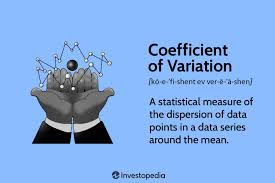

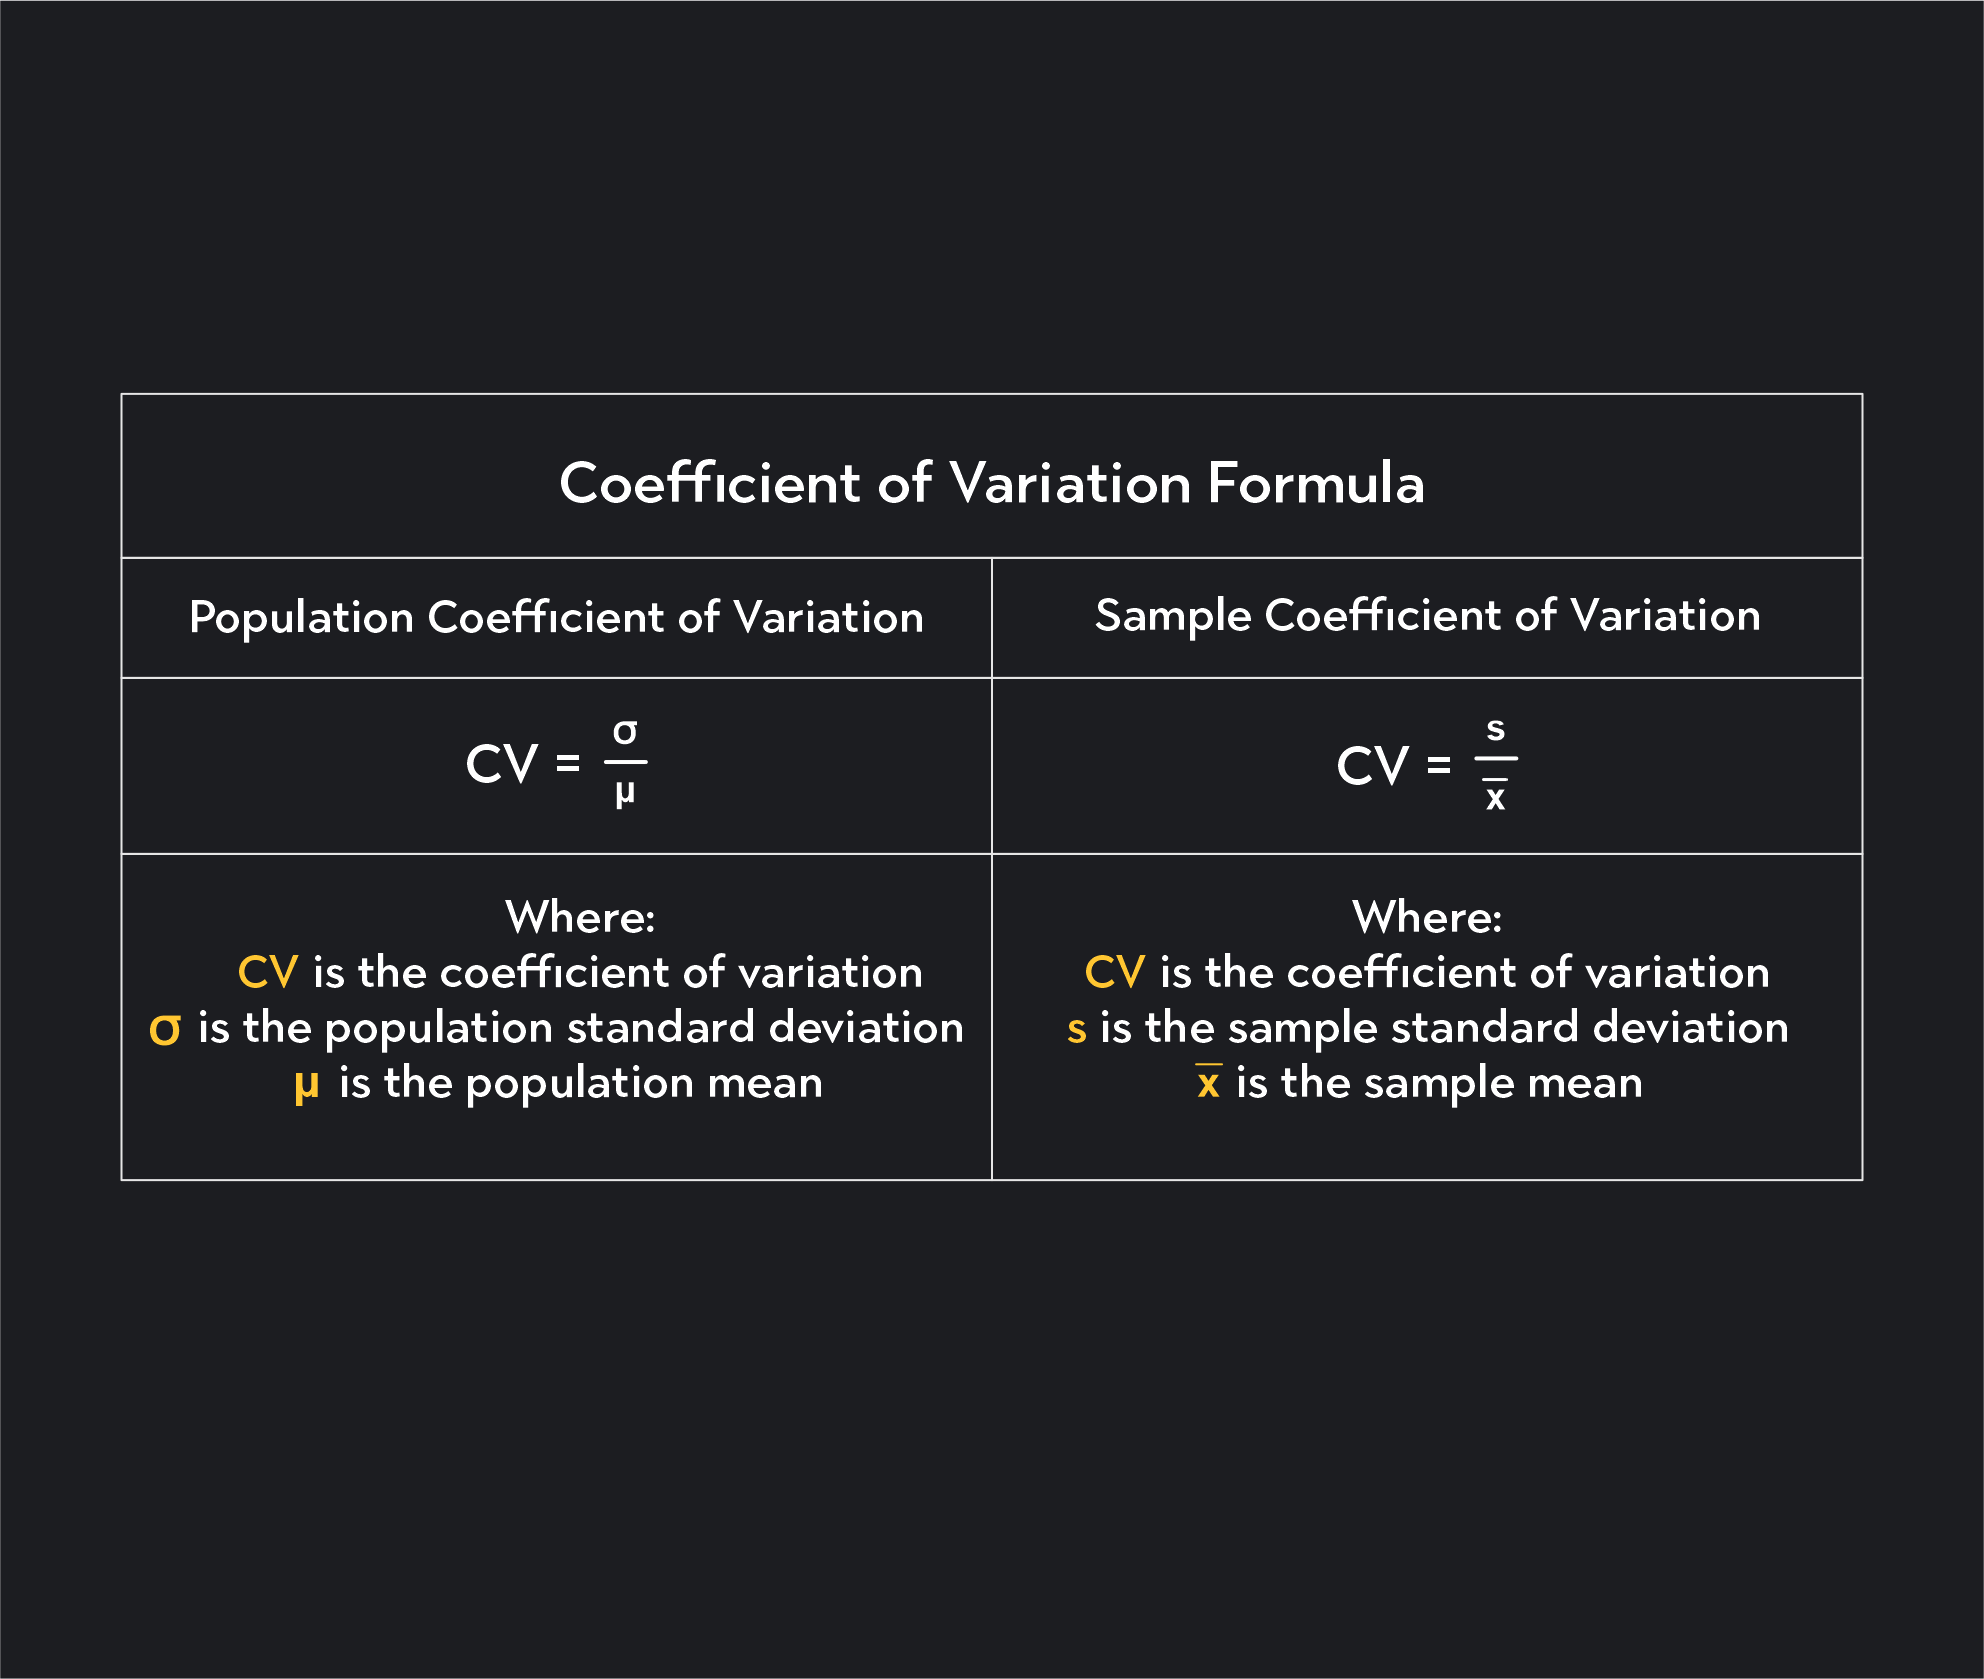

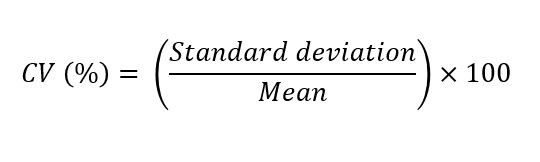

> Increasing the number of reads can improve the assay precision and thus reduce the coefficient of variation of the control group.
>
> Different algorithms have been  developed to increase precision, by reducing the variation in the control group, e.g. GC correction, or by using  an adapted Z-score calculation, such as the normalised chromosome value.
>
> 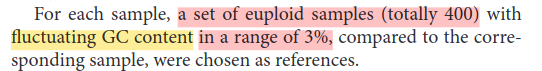
>
> The coefficient of variation is used in combination with the percentage of foetal DNA to compute the expected distance between the two Gaussian distributions for diploid pregnancies and trisomic pregnancies.
>

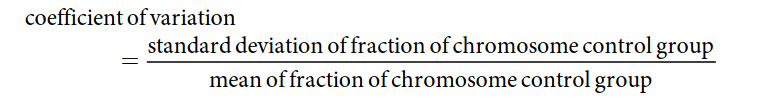

> As the coefficient of variation increases, the distance between the diploid and aneuploid distribution will decrease, resulting in a decrease of sensitivity for detecting a trisomy.


> For example, a coefficient of variation of `0.5%` for chromosome 21 would result in `99.87%` sensitivity at a foetal DNA percentage of `6%`, while the sensitivity would drop to `84.13%` at a foetal DNA percentage of `4%`. A `99.87%` sensitivity at `4%` foetal DNA can only be obtained with a coefficient of variation of `0.33%`.
>
> Thus, a higher coefficient of variation will decrease the sensitivity, especially at low percentages of foetal DNA. 
> 
> A coefficient of variation of 0.5% (chromosome 21) is used as the default setting in our program because this is close to empirically measured values.
>  
> For chromosomes 13 and 18, we recommend 0.4% as a default setting.
>
> The number of reads is higher for these chromosomes, leading to the expectation of a **lower coefficient of variation** than for chromosome 21. However, if the coefficient of variation is measured and lower than our default setting, this value should be used for a more accurate PPR calculation.

How can I compute the coefficient of variation in my data?

| Feature                 | **Variance**                                                            | **Coefficient of Variation (CV)**                                                            |
| ----------------------- | ----------------------------------------------------------------------- | -------------------------------------------------------------------------------------------- |
| **Definition**          | A measure of how far data points spread out from the mean.              | A standardized measure of relative variability (ratio of standard deviation to mean).        |
| **Formula**             | $\text{Var}(X) = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2$             | $\text{CV} = \frac{\sigma}{\mu} \times 100\%$                                                |
| **Units**               | Square of the units of the data (e.g., if data in cm, variance in cm²). | Dimensionless (no units, expressed as a percentage).                                         |
| **Dependence on Scale** | Scale-dependent (sensitive to units of measurement).                    | Scale-independent (normalizes variability relative to mean).                                 |
| **Interpretation**      | Indicates **absolute spread** of data around the mean.                  | Indicates **relative spread** (useful for comparing datasets with different units or means). |
| **Range**               | $\geq 0$ (cannot be negative).                                          | Usually $\geq 0$, but undefined if mean ($\mu = 0$).                                         |
| **Use Case**            | Best for analyzing spread within a single dataset.                      | Best for comparing variability **between datasets** with different units or scales.          |
| **Example**             | Variance of exam scores (points²).                                      | CV of exam scores (%), useful to compare across different tests.                             |


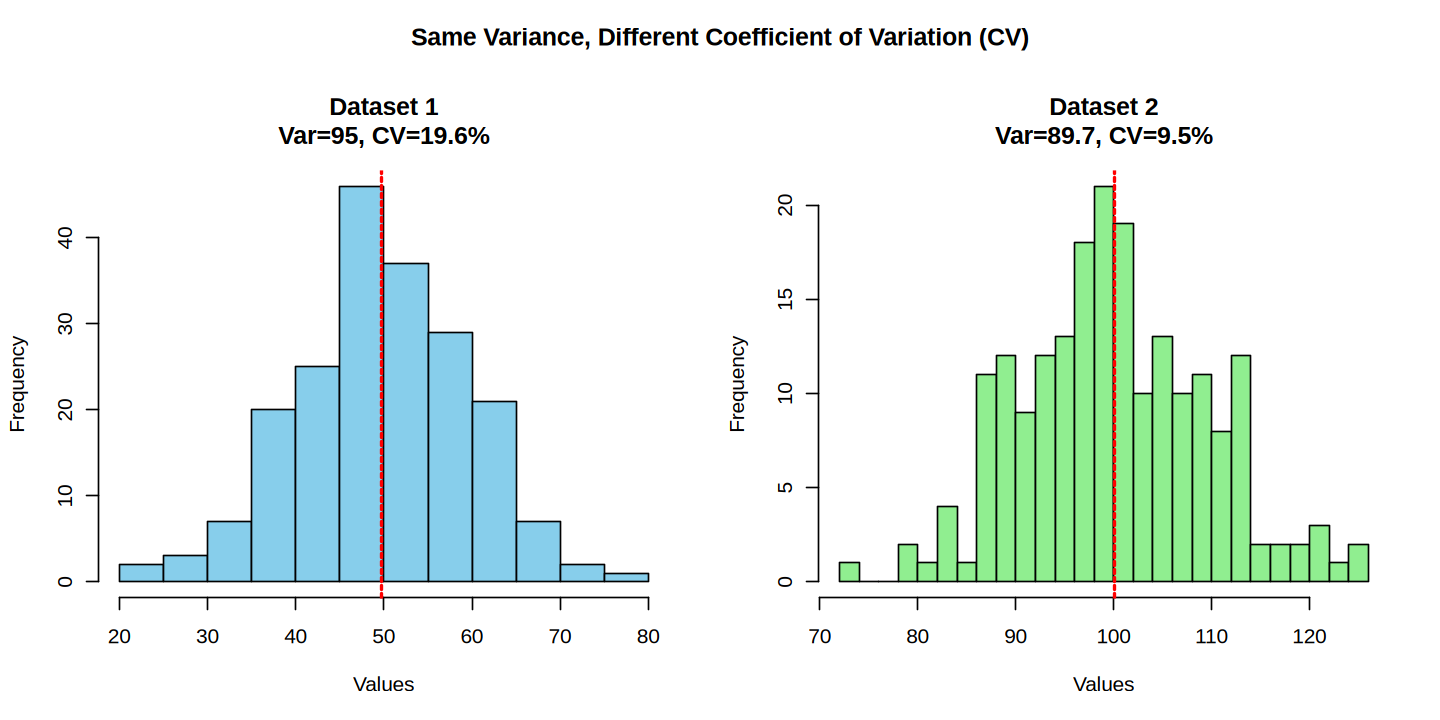

In [4]:
#| echo: false


options(repr.plot.width=12, repr.plot.height=6)
# Generate two datasets: same variance, different means
set.seed(42)
data1 <- rnorm(200, mean = 50, sd = 10)   # mean = 50
data2 <- rnorm(200, mean = 100, sd = 10)  # mean = 100

# Compute variance and CV
var1 <- var(data1)
var2 <- var(data2)
cv1 <- sd(data1) / mean(data1) * 100
cv2 <- sd(data2) / mean(data2) * 100

# Set up the layout with more space for the title
par(mfrow = c(1,2), oma = c(0, 0, 3, 0))  # increased outer margin for the title

hist(data1, breaks = 20, col = "skyblue", border = "black",
    main = paste0("Dataset 1\nVar=", round(var1,1), ", CV=", round(cv1,1), "%"),
    xlab = "Values")
abline(v = mean(data1), col = "red", lwd = 2, lty = 2)

hist(data2, breaks = 20, col = "lightgreen", border = "black",
    main = paste0("Dataset 2\nVar=", round(var2,1), ", CV=", round(cv2,1), "%"),
    xlab = "Values")
abline(v = mean(data2), col = "red", lwd = 2, lty = 2)

# Add the overall title with more space
mtext("Same Variance, Different Coefficient of Variation (CV)", 
     outer = TRUE, line = 1, cex = 1.2, font = 2)


### PPR calculation
The PPR calculation is made as follows. 

First, the expected Z-score, if a trisomy is present, is calculated using the coefficient of variation of the control group and the percentage of foetal DNA:

```Z expected = (percentage of foetal DNA × 0.5)/(100 × coefficient of variation)```

Why this formula works:

- In a trisomy, there's a 50% increase in chromosome material (× 0.5)
- The 100 in the denominator converts to percentage format
- CV represents test variability - lower CV means more reliable detection

#### What is Z-Expected?

> Z-expected is the theoretical z-score we would expect to observe if a fetus has a trisomy (like Down syndrome), given:

- The fetal fraction (percentage of fetal DNA in maternal blood)
- The test's coefficient of variation (measurement precision)

#### The Formula Logic

```
Z expected = (percentage of foetal DNA × 0.5) / (100 × coefficient of variation)
```

Let's dissect each component:

**1. Why × 0.5 (50% increase)?**

In a trisomy 21 pregnancy:

- Normal pregnancies have 2 copies of chromosome 21
- Trisomy 21 pregnancies have 3 copies of chromosome 21
- This represents a 50% increase in chromosome 21 material (3/2 = 1.5, so +0.5 or +50%)

**2. Why ÷ 100?**

This converts the percentage to a decimal format for the calculation.

**3. Why ÷ coefficient of variation?**

The CV represents the "noise" or variability in your measurement system:

- Lower CV = more precise measurements = easier to detect small changes
- Higher CV = less precise measurements = harder to detect small changes

The z-score measures "how many standard deviations away from normal" a measurement is. A more precise test (lower CV) will show the same biological difference as a higher z-score.

### Concrete Example

Let's work through a real example:

**Scenario:**

- Fetal fraction = 8%
- CV = 0.5% (high-quality test)

**Calculation:**

```
Z expected = (8 × 0.5) / (100 × 0.005) = 4 / 0.5 = 8.0
```

Interpretation: If this pregnancy has trisomy 21, we expect to see a z-score around 8.0.

What if the test was less precise?

- Same fetal fraction = 8%
- CV = 1.5% (lower quality test)


```
Z expected = (8 × 0.5) / (100 × 0.015) = 4 / 1.5 = 2.67
```

The less precise test would only show a z-score around 2.67 for the same biological condition.

### Visual Understanding

Imagine two bell curves representing chromosome 21 percentages:

1. Normal pregnancies: Centered at ~2.0%
2. Trisomy 21 pregnancies: Centered at ~2.0% + (fetal_fraction × 0.5)%

The `distance between these curves` (measured in standard deviations) is the Z-expected.

[1] "Z-expected = 8"


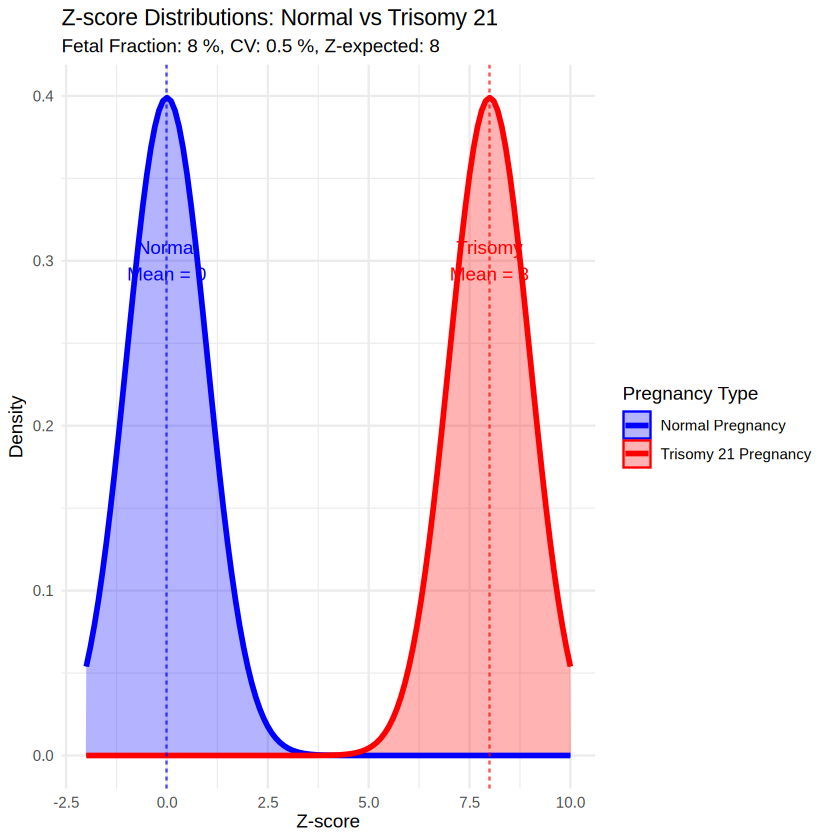

In [2]:
#| echo: false
#| warning: false
#| message: false

# Visualization example
library(ggplot2)

# Example with 8% fetal fraction, 0.5% CV
fetal_fraction <- 8
cv <- 0.005
z_expected <- (fetal_fraction * 0.5) / (100 * cv)

print(paste("Z-expected =", z_expected))

# Create visualization of the two distributions
library(tidyverse)

# Generate data for the two distributions
x <- seq(-2, 10, by = 0.1)
normal_dist <- dnorm(x, mean = 0, sd = 1)
trisomy_dist <- dnorm(x, mean = z_expected, sd = 1)

# Create dataframe for plotting
dist_data <- data.frame(
    x = rep(x, 2),
    density = c(normal_dist, trisomy_dist),
    distribution = rep(c("Normal Pregnancy", "Trisomy 21 Pregnancy"), each = length(x))
)

# Create the plot
ggplot(dist_data, aes(x = x, y = density, fill = distribution, color = distribution)) +
    geom_area(alpha = 0.3, position = "identity") +
    geom_line(size = 1.2) +
    scale_fill_manual(values = c("Normal Pregnancy" = "blue", "Trisomy 21 Pregnancy" = "red")) +
    scale_color_manual(values = c("Normal Pregnancy" = "blue", "Trisomy 21 Pregnancy" = "red")) +
    labs(
        title = paste("Z-score Distributions: Normal vs Trisomy 21"),
        subtitle = paste("Fetal Fraction:", fetal_fraction, "%, CV:", cv*100, "%, Z-expected:", round(z_expected, 1)),
        x = "Z-score",
        y = "Density",
        fill = "Pregnancy Type",
        color = "Pregnancy Type"
    ) +
    theme_minimal() +
    geom_vline(xintercept = 0, linetype = "dashed", color = "blue", alpha = 0.7) +
    geom_vline(xintercept = z_expected, linetype = "dashed", color = "red", alpha = 0.7) +
    annotate("text", x = 0, y = 0.3, label = "Normal\nMean = 0", color = "blue", hjust = 0.5) +
    annotate("text", x = z_expected, y = 0.3, label = paste("Trisomy\nMean =", round(z_expected, 1)), 
                     color = "red", hjust = 0.5)


### Why This Matters for PPR Calculation

The Z-expected tells us:

1. How far apart the normal and trisomy distributions should be
2. How confident we can be in our test result
3. What range of z-scores we might expect due to biological variability

Clinical Implications:

- **High Z-expected (>4):** Even moderate observed z-scores strongly suggest trisomy
- **Low Z-expected (<2):** Need very high observed z-scores to be confident
- **Very low fetal fraction** or **high CV**: May not be able to reliably detect trisomy

### Key Insights

1. **Fetal fraction is crucial**: Higher fetal fraction = easier detection
2. **Test precision matters**: Lower CV = better separation of normal vs. trisomy
3. **The 50% factor is biological**: Reflects the extra chromosome copy in trisomy
4. **Z-expected sets expectations**: Helps interpret whether an observed z-score is significant

This is why NIPT labs often have minimum fetal fraction thresholds (usually 4%) - below this, the Z-expected becomes too low for reliable trisomy detection.

Why CV has the unit of percentage (%)?

##### Z-score Distribution Modeling

> The actual Z-score in the case of a trisomy is a random variable with the “Z expected” value and standard deviation both equal to 1.0.

##### Fetal Fraction Integration

> Because the percentage of foetal DNA cannot be exactly measured, the empirical distribution of Z-scores will be a weighted sum of distributions over all possible values for the foetal DNA percentage.
>
> > A weighted sum is a method for combining values where each value is multiplied by a specific weight, representing its relative importance, and then these products are summed together.

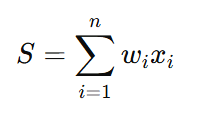

> Technically, this percentage is a nuisance parameter that is integrated out to compute the probability that the observed Z-score originates from a trisomic pregnancy.

This uses a statistical technique called "nuisance parameter integration" where:

- A range of possible fetal fractions is considered
- Each possible value contributes to the final probability calculation
- The model converts fetal DNA percentage to expected Z-score ranges


> In our computational model, we allow the range for the foetal DNA percentage to be known and input exactly.

> The actual integration of the nuisance parameter of foetal percentage is done by converting the foetal DNA percentage to a lower and upper value for the expected Z- score. 

The post-test probability or personalised a posteriori risk (PPR) is calculated as:

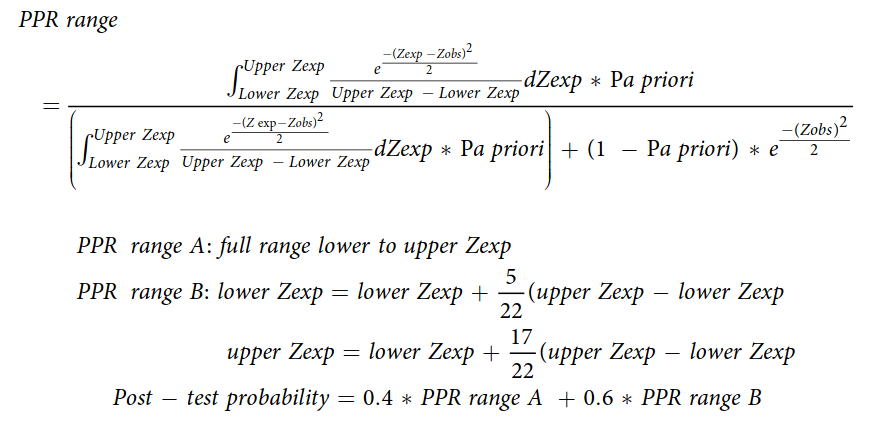

##### The Core Concept

The formula uses Bayesian statistics to answer: "Given this z-score result, what's the probability this pregnancy has trisomy 21?"

##### The Formula Explained Simply

The formula calculates PPR by integrating over a range of possible expected z-scores (Zexp), since fetal fraction can't be measured precisely.

`The Numerator (Top Part)`

$$
\int_{Lower Z_{exp}}^{Upper Z_{exp}} \frac{e^{-(Z_{exp}-Z_{obs})^2/2}}{Upper Z_{exp} - Lower Z_{exp}} \, dZ_{exp} \times P_{a \ priori}
$$

This represents:

- The probability of observing the measured z-score (Zobs) if the fetus has trisomy
- Multiplied by the prior risk (Pa priori)

`The Denominator (Bottom Part)`

$$
\int_{Lower Z_{exp}}^{Upper Z_{exp}} \frac{e^{-(Z_{exp}-Z_{obs})^2/2}}{Upper Z_{exp} - Lower Z_{exp}} \, dZ_{exp} \times P_{a \ priori} + (1 - P_{a \ priori}) \times e^{-Z_{obs}^2/2}
$$

This adds:

- The same calculation as the numerator (probability if trisomy × prior risk)
- The probability of observing this z-score in a normal pregnancy × prior probability of normal

##### The Range Calculations

The formula defines two different ranges for integration:

1. Range A: Uses the full range from lower to upper expected z-score
2. Range B: Uses a narrower range:
   - Lower bound = Lower Zexp + 5/22 × (Upper Zexp - Lower Zexp)
   - Upper bound = Lower Zexp + 17/22 × (Upper Zexp - Lower Zexp)


The final PPR is a weighted average:

```
Post-test probability = 0.4 × PPR range A + 0.6 × PPR range B
```

##### In Plain Language

This formula:

1. Starts with your baseline risk based on maternal age
2. Adjusts this risk based on how your z-score compares to what we'd expect for normal and trisomy pregnancies
3. Accounts for uncertainty in fetal fraction by considering a range of possible values
4. Gives more weight (60%) to the central part of the distribution where most real values likely fall

This produces a personalized risk assessment that's more accurate than simply using a threshold z-score or only considering maternal age.

#### Examples of the use of the PPR calculator.

To demonstrate the use of the calculator and the effects of varying a priori risk values and observed Z-scores on the PPR, we have generated tables and concomitant figures. 

In order to clarify the calculations, we: 

- fixed the coefficient of variation at 0.5 and 
- used a range of 1–23% of cell-free foetal DNA. 

The PPR was calculated as a percentage for:

- a priori risks of `0.0001, 0.0002, 0.0005, 0.0010, 0.0015, 0.0020, 0.0025, 0.0050, 0.0100, 0.0250, 0.0500` and `0.1000`, 
- for observed Z-scores of `2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5` and `6`.

To demonstrate the additional effect on the PPR of variable foetal DNA percentages in maternal blood, the PPR was calculated for an a priori risk of `0.001`, `0.01` and `0.1`, for Z-scores varying from `0` to `7` and foetal DNA varying from `3%` to `10%`.

#### Performance of the PPR calculator

To test the performance of our PPR calculator, we analysed 209 maternal blood samples obtained from pregnant women with an elevated risk for trisomy 13, 18 or 21 due to an FTC > 1:200 between 10 and 16 weeks of gestation.

likelihood ratio

discriminate likelihood ratio and probability:

- **Probability**: varies the data while keeping parameters fixed.

- **Likelihood**: varies the parameters while keeping the data fixed.

coefficient of variation

intersection and union

numerator

denominator

Bayesian post-test risk modeling

----

# Conditional Probability

Conditional probability is the foundation of the Bayesian approach used in NIPT. Let's break it down using intuitive examples from prenatal testing.

## The Basic Concept

Conditional probability is about how the probability of one event changes when we know another event has occurred. 

We write it as `P(A|B)`, which means "the probability of A given that B has happened."

## NIPT Example: Understanding Conditional Probability


Let's work with a concrete example:

**1. Basic Probabilities in NIPT**

- `P(T21)` = Probability a baby has trisomy 21 (Down syndrome)

- `P(Positive)` = Probability of getting a positive test result
- `P(T21|Positive)` = Probability baby has Down syndrome given a positive test
- `P(Positive|T21)` = Probability of a positive test given the baby has Down syndrome

**2. Real-World NIPT Scenario**

Imagine 10,000 pregnant women being tested:

- 100 babies have Down syndrome (`P(T21)` = 100/10,000 = 0.01 or 1%)
- 99 of those 100 babies with Down syndrome test positive (`sensitivity` = 99%)
- 9,900 babies don't have Down syndrome
- 10 of those 9,900 babies without Down syndrome test positive (`false positive rate` = 0.1%)
- Total positive tests: 99 + 10 = 109

**3. Conditional Probability in Action**
  
`P(Positive|T21) = 99/100 = 0.99 (99%)`

This is the test sensitivity

> "If a baby has Down syndrome, there's a 99% chance the test is positive"

`P(T21|Positive) = 99/109 ≈ 0.908 (90.8%)`

This is the positive predictive value

> "If the test is positive, there's a 90.8% chance the baby has Down syndrome"

## Why Z-scores Matter in Conditional Probability

The z-score in NIPT is a continuous measure, not a binary yes/no:

- `P(T21|z=3)` might be 50%
- `P(T21|z=5)` might be 80%
- `P(T21|z=7)` might be 95%

> This shows how the condition (the z-score value) dramatically changes the probability of the baby having Down syndrome.

## How Prior Risk Affects Conditional Probability

For a 25-year-old mother (baseline risk 0.1%):

- Out of 10,000 pregnancies, only 10 babies have Down syndrome (`P(T21)`)

- With the same test characteristics, a positive result gives `P(T21|Positive)` ≈ 50%

- This demonstrates how the conditional probability `P(T21|Positive)` depends heavily on the population being tested.

## Example: Visualizing Conditional Probability in NIPT

In [4]:
#| label: conditional-probability-nipt
#| fig.width: 9
#| fig.height: 6
#| warning: false
#| message: false
#| echo: false

library(tidyverse)
library(scales)
library(kableExtra)


Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows




Given the z-score from 1 to 8

In [36]:
#| warning: false
#| message: false
#| echo: false

# Create a dataframe showing relationship between z-scores and conditional probability
# Based on realistic but simulated data

# Z-score range
z_scores <- seq(1, 8, by = 0.5)
z_scores

[1] 1.0 1.5 2.0 2.5 3.0 3.5 4.0 4.5 5.0 5.5 6.0 6.5 7.0 7.5 8.0

In [37]:
# Function to calculate P(T21|z) for different age groups
# Parameters estimated based on typical NIPT results
calculate_pt21_given_z <- function(z, prior_risk) {
  # Likelihood ratio increases exponentially with z-score
  lr <- exp(0.8 * z - 2)
  # Apply Bayes theorem
  posterior <- (prior_risk * lr) / (prior_risk * lr + (1 - prior_risk))
  return(posterior)
}

This is calculating `P(T21|z)` - the probability of trisomy 21 given a specific z-score.

**How It Works**

- The z-score represents the number of standard deviations from the expected normal DNA fraction
- Higher z-scores indicate a higher likelihood of trisomy 21
- The function converts z-scores to likelihood ratios using exp(0.8 * z - 2)
- Then applies Bayes' theorem to calculate the posterior probability

```
lr <- exp(0.8 * z - 2)
```

This formula calculates the likelihood ratio (LR) from a z-score in your NIPT analysis.

For different z-scores, this formula produces:

- z=1: LR ≈ 0.135 (strong evidence against T21)
- z=2.5: LR ≈ 1.0 (neutral evidence)
- z=4: LR ≈ 7.4 (moderate evidence for T21)
- z=6: LR ≈ 54.6 (strong evidence for T21)
- z=8: LR ≈ 403.4 (overwhelming evidence for T21)

These values produce the beautiful curves in your visualization, showing how:

1. At low z-scores (1-4), prior risk still strongly influences posterior probability
2. At high z-scores (6+), the likelihood ratio becomes so high that it overwhelms the prior risk

In statistics, Probability is not Likelihood

https://www.youtube.com/watch?v=pYxNSUDSFH4&t=165s

In [39]:
#| warning: false
#| message: false
#| echo: false

# Create dataframe with probabilities for different age groups
nipt_df <- expand.grid(
  z_score = z_scores,
  age_group = c("20-25 yrs (0.1%)", "30-35 yrs (0.3%)", "35-40 yrs (0.8%)", "40+ yrs (1.5%)")
)

# Set prior risks based on age groups
prior_risks <- c(0.001, 0.003, 0.008, 0.015)
names(prior_risks) <- c("20-25 yrs (0.1%)", "30-35 yrs (0.3%)", "35-40 yrs (0.8%)", "40+ yrs (1.5%)")

prior_risks

# Calculate conditional probabilities
nipt_df$conditional_prob <- mapply(
  calculate_pt21_given_z,
  nipt_df$z_score,
  prior_risks[nipt_df$age_group]
)

20-25 yrs (0.1%) 30-35 yrs (0.3%) 35-40 yrs (0.8%)   40+ yrs (1.5%) 
           0.001            0.003            0.008            0.015

In [40]:
nipt_df |> head(20)

,z_score,age_group,conditional_prob
,<dbl>,<fct>,<dbl>
1,1.0,20-25 yrs (0.1%),0.0003014048
2,1.5,20-25 yrs (0.1%),0.0004495765
3,2.0,20-25 yrs (0.1%),0.0006705411
4,2.5,20-25 yrs (0.1%),0.0010000000
5,3.0,20-25 yrs (0.1%),0.0014910913
6,3.5,20-25 yrs (0.1%),0.0022228168
7,4.0,20-25 yrs (0.1%),0.0033124317
8,4.5,20-25 yrs (0.1%),0.0049335300
9,5.0,20-25 yrs (0.1%),0.0073421467


How `P(T21|z-score)` changes based on different z-scores and starting risks.

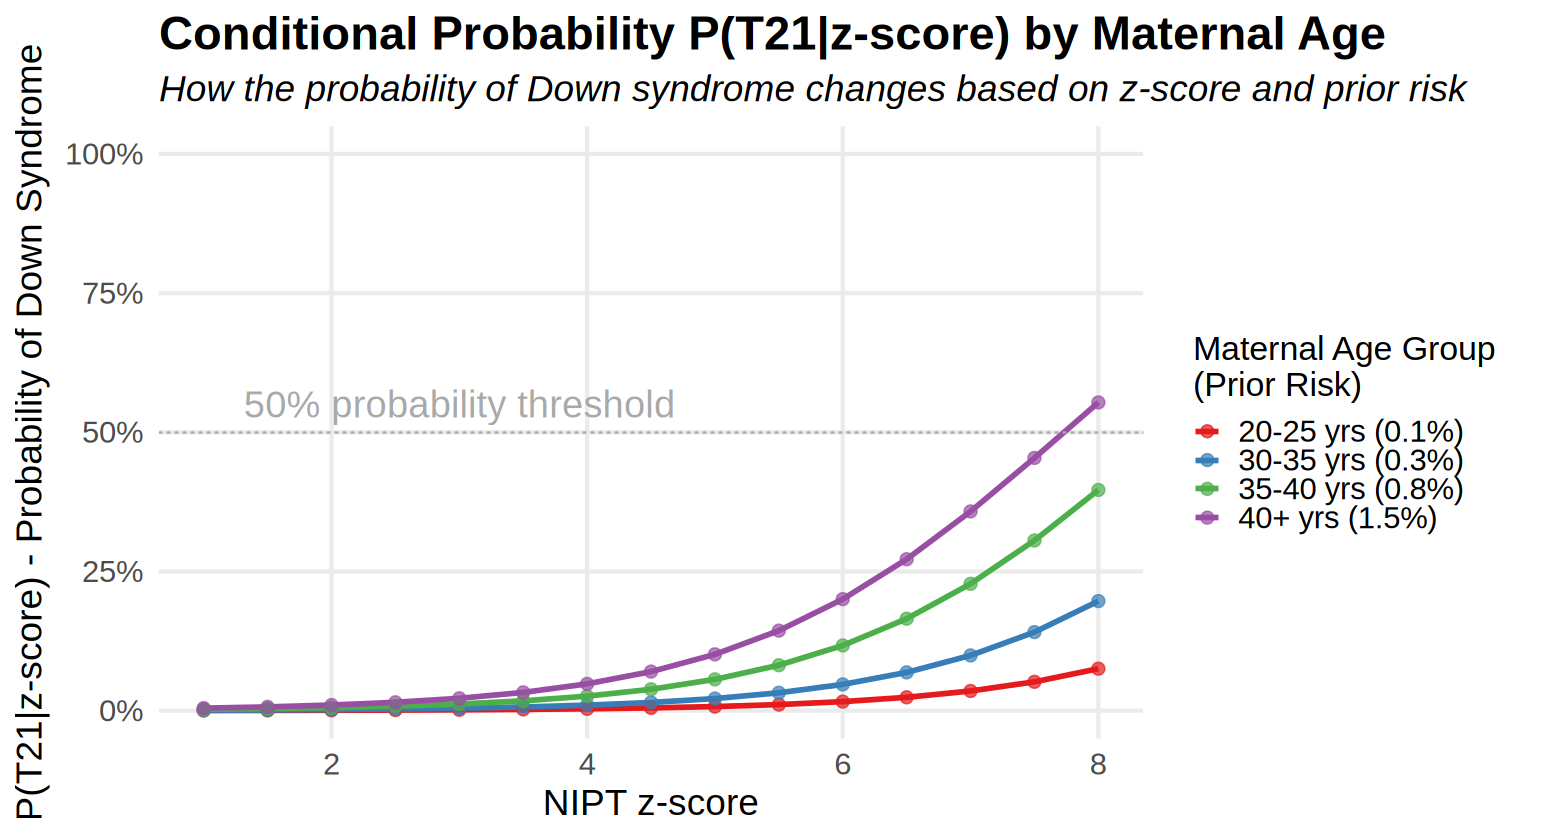

In [34]:
#| fig.width: 12
#| fig.height: 6
#| warning: false
#| message: false
#| echo: false

options(repr.plot.width = 13, repr.plot.height = 7)
ggplot(nipt_df, aes(x = z_score, y = conditional_prob, color = age_group)) +
  geom_line(size = 1.2) +
  geom_point(size = 3, alpha = 0.7) +
  scale_y_continuous(labels = percent_format(), limits = c(0, 1)) +
  scale_color_brewer(palette = "Set1") +
  labs(
    title = "Conditional Probability P(T21|z-score) by Maternal Age",
    subtitle = "How the probability of Down syndrome changes based on z-score and prior risk",
    x = "NIPT z-score",
    y = "P(T21|z-score) - Probability of Down Syndrome",
    color = "Maternal Age Group\n(Prior Risk)"
  ) +
  theme_minimal(base_size = 20) + # Increase base font size
  theme(
    legend.position = "right",
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", size = 28),
    plot.subtitle = element_text(face = "italic", size = 22),
    axis.title = element_text(size = 22),
    axis.text = element_text(size = 18),
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 18),
    strip.text = element_text(size = 20)
  ) +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "darkgray") +
  annotate("text", x = 3, y = 0.55, label = "50% probability threshold", color = "darkgray", size = 8)

In [29]:
#| fig.width: 12
#| fig.height: 6
#| warning: false
#| message: false
#| echo: false

# Create a sample data table for the explanation
sample_data <- data.frame(
  z_score = c(3, 3, 3, 3, 7, 7, 7, 7),
  age_group = rep(c("20-25 yrs", "30-35 yrs", "35-40 yrs", "40+ yrs"), 2),
  prior_risk = rep(c(0.001, 0.003, 0.008, 0.015), 2),
  posterior_risk = c(
    0.018, 0.052, 0.129, 0.219,  # For z=3
    0.883, 0.957, 0.985, 0.992   # For z=7
  )
)

library(IRdisplay)

html_table <- kable(sample_data, 
    col.names = c("Z-score", "Age Group", "Prior Risk", "Posterior Risk P(T21|z)"),
    caption = "Example of how conditional probability changes with z-score and prior risk",
    format = "html",
    escape = FALSE) %>%
  kable_styling(bootstrap_options = c("striped", "hover", "condensed"), full_width = FALSE) %>%
  row_spec(0, bold = TRUE) %>%
  row_spec(4:8, background = "#ffffd9")

display_html(as.character(html_table))

Z-score,Age Group,Prior Risk,Posterior Risk P(T21|z)
3,20-25 yrs,0.001,0.018
3,30-35 yrs,0.003,0.052
3,35-40 yrs,0.008,0.129
3,40+ yrs,0.015,0.219
7,20-25 yrs,0.001,0.883
7,30-35 yrs,0.003,0.957
7,35-40 yrs,0.008,0.985
7,40+ yrs,0.015,0.992


$$
\text{Posterior Risk} = \frac{\frac{1}{100} \times 0.99}{\left(\frac{1}{100} \times 0.99\right) + \left(\frac{99}{100} \times 0.001\right)}
\approx 0.99 \text{ or } 99\%
$$

## Intuitive Takeaways

-   **Context matters**: The meaning of a positive test depends on who's being tested

-   **Conditioning changes probabilities**: The probability of Down syndrome changes dramatically when conditioned on test results

-   **Visual intuition**: The higher the z-score, the more it "conditions" our understanding of the risk

-   **Practical interpretation**: When a doctor says "given your positive test and age, your risk is X%," they're applying conditional probability

Conditional probability helps us understand that test results don't exist in isolation—they must be interpreted in the context of prior risk factors and test performance characteristics.

## References & Learning resources

https://en.wikipedia.org/wiki/Conditional_probability

1.  Intro to Conditional Probability: [Youtube](https://www.youtube.com/watch?v=ibINrxJLvlM)

![alt text](image-2.png)

![alt text](image-3.png)

![alt text](image-5.png)

![alt text](image-4.png)

2.  Two Conditional Probability Examples (what's the difference???) [Youtube](https://www.youtube.com/watch?v=OYT0AcuLXu8)
3.  Conditional Probabilities, Clearly Explained!!! [Youtube](https://www.youtube.com/watch?v=_IgyaD7vOOA&t=44s)